## Recommendation-Oriented Analysis

This module is the fifth task in the project and the one with the most direct business value. Building on the previous four tasks:
- **Task 1**: Data Preprocessing (handling missing values, extracting time features)
- **Task 2**: Performance Benchmark (comprehensive Pandas vs. Polars comparison)
- **Task 3**: Baseline EDA (event distribution, time trends, user activity)
- **Task 4**: User Behavior Pattern Analysis (conversion funnel, new vs. returning user paths, session depth)

This task focuses on **Association Rule Mining**, discovering implicit associations among products, categories, and brands from actual purchase behavior, and outputting recommendation strategies that can directly guide business decisions.

### Analysis Directions
1. **Category Association Rule Mining**: identify which top-level categories are frequently purchased together in the same session, supporting "Recommended for You" category suggestions.
2. **Brand Association Rule Mining**: find high-frequency co-occurring brand combinations to guide bundle promotions and co-marketing campaigns.
3. **Product-Level Association Analysis**: extract precise SKU recommendation rules for the Top-100 best-selling products.

### Key Constraints (strictly enforced)
- **Association rule mining only** (based on frequent itemsets); deep learning, collaborative filtering neural networks, and other complex ML models are strictly prohibited.
- All metrics — **Support**, **Confidence**, **Lift** — are computed directly from statistical counts.
- Each analysis module includes both Pandas and Polars implementations for performance comparison.

### Cell 1: Environment Initialization and Monitoring Framework

1. **Business Logic**: Inherits the monitoring framework validated in Task 4, ensuring performance metrics are consistent across the entire project.

2. **Technical Design**:
   - `MemoryMonitor`: A daemon thread that samples system memory every 0.1 seconds without interfering with the main computation; automatically triggers a circuit breaker if the safety limit is exceeded.
   - `run_benchmark`: Unified wrapper that captures execution time, peak memory, and memory delta.
   - `generate_pairs_from_baskets`: Core helper for association rule mining — extracts all unordered item pairs from basket lists; shared across all three analysis directions.

3. **Data Note**: Loads 100% of the cleaned dataset (11.5M rows), reusing the standardized Parquet file generated in Task 1 — no re-preprocessing needed.

In [1]:
import pandas as pd
import polars as pl
import time
import threading
import psutil
import gc
import itertools
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Configuration: dataset path and memory safety limit
DATA_PATH = "artifacts/clean_subsets/train_clean_100pct.parquet"
SAFE_LIMIT_GB = 12.0  # Recommended: 70%–80% of physical RAM

# ── Monitoring framework inherited from Task 4 (consistent metrics across tasks) ──
class MemoryMonitor(threading.Thread):
    """Non-blocking memory monitor thread: samples peak memory every 0.1 s; auto-trips circuit breaker on limit exceeded."""
    def __init__(self, delay=0.1, max_gb=None):
        super().__init__(daemon=True)
        self.stopped = False
        self.delay = delay
        self.peak_memory = 0
        self.max_gb = max_gb
        self.exceeded = False
        self.start_mem = psutil.Process().memory_info().rss / (1024**3)

    def run(self):
        while not self.stopped:
            cur_mem = psutil.Process().memory_info().rss / (1024**3)
            if cur_mem > self.peak_memory:
                self.peak_memory = cur_mem
            if self.max_gb and cur_mem > self.max_gb:
                self.exceeded = True
                break
            time.sleep(self.delay)

def run_benchmark(func, name, *args, **kwargs):
    """Unified benchmark wrapper: records execution time, peak memory, and memory delta."""
    gc.collect()
    monitor = MemoryMonitor(max_gb=SAFE_LIMIT_GB)
    monitor.start()
    start_t = time.perf_counter()

    result = None
    try:
        result = func(*args, **kwargs)
        status = "Success"
    except Exception as e:
        status = f"Error: {e}"

    end_t = time.perf_counter()
    monitor.stopped = True
    monitor.join()

    metrics = {
        "Name": name,
        "Time (s)": round(end_t - start_t, 4),
        "Peak Mem (GB)": round(monitor.peak_memory, 4),
        "Delta Mem (GB)": round(monitor.peak_memory - monitor.start_mem, 4),
        "Status": "MEM_EXCEEDED" if monitor.exceeded else status
    }
    return result, metrics


# ── Core helper function for association rule mining ────────────────────────────────────
def generate_pairs_from_baskets(baskets: list) -> list:
    """
    Generate all unordered item pairs from a list of baskets.
    Input: baskets -- each element is a set of products/categories/brands from one session
    Output: list of all (A, B) pairs (sorted A < B lexicographically, deduplication guaranteed)
    """
    pairs = []
    for basket in baskets:
        # Deduplicate, remove nulls, cast to sortable string type
        items = sorted(set(
            str(x) for x in basket
            if x is not None and str(x) not in ('None', 'nan', '')
        ))
        if len(items) >= 2:
            pairs.extend(itertools.combinations(items, 2))
    return pairs


def compute_association_rules(pairs: list, item_counts: dict, total_sessions: int,
                               min_support: float = 0.005,
                               min_confidence: float = 0.1) -> pd.DataFrame:
    """
    Compute the three core metrics for association rules:
    - Support   = P(A and B) = sessions containing both A and B / total sessions
    - Confidence = P(B|A) = P(A and B) / P(A)
    - Lift = Confidence(A->B) / Support(B); >1 means positive correlation
    """
    pair_counts = Counter(pairs)
    rules = []

    for (a, b), count in pair_counts.items():
        support_ab = count / total_sessions
        if support_ab < min_support:
            continue

        support_a = item_counts.get(a, 1) / total_sessions
        support_b = item_counts.get(b, 1) / total_sessions

        # Direction A -> B
        conf_ab = support_ab / support_a if support_a > 0 else 0
        lift_ab = conf_ab / support_b if support_b > 0 else 0
        if conf_ab >= min_confidence:
            rules.append({
                'antecedent': a, 'consequent': b,
                'support': round(support_ab, 6),
                'confidence': round(conf_ab, 4),
                'lift': round(lift_ab, 4),
                'co_count': count
            })

        # Direction B -> A (bidirectional symmetric mining)
        conf_ba = support_ab / support_b if support_b > 0 else 0
        lift_ba = conf_ba / support_a if support_a > 0 else 0
        if conf_ba >= min_confidence:
            rules.append({
                'antecedent': b, 'consequent': a,
                'support': round(support_ab, 6),
                'confidence': round(conf_ba, 4),
                'lift': round(lift_ba, 4),
                'co_count': count
            })

    if not rules:
        return pd.DataFrame(columns=['antecedent','consequent','support','confidence','lift','co_count'])
    return pd.DataFrame(rules).sort_values('lift', ascending=False).reset_index(drop=True)


# -- Pre-load Pandas DataFrame (reused by all subsequent Pandas tasks to avoid repeated I/O) --────
print('Loading dataset...')
df_pd = pd.read_parquet(DATA_PATH)
print(f'Dataset loaded: {df_pd.shape[0]:,} rows x {df_pd.shape[1]} columns')
print(f'Event type distribution:\n{df_pd["event_type"].value_counts().to_string()}')
print('\nMonitoring framework and helper functions ready. Starting recommendation-oriented analysis ✓')

正在加载数据集...
数据集加载完成：11,487,615 行 × 26 列
事件类型分布：
event_type
cart        7297415
purchase    4190200

监控框架与辅助函数已就绪，开始推荐导向分析 ✓


### Cell 2: Transaction Basket Construction — Category Level

1. **Business Logic**:
   The core input for association rule mining is "shopping basket" data: each row represents a session containing the set of all categories purchased in that session.
   We use `user_session` as the transaction unit and `cat_0` (top-level category) as the item proxy, keeping only sessions with **≥2 distinct categories** (single-category sessions cannot produce rules).

2. **Technical Design**:
   - **Why cat_0 instead of product_id**: `cat_0` has only ~5–10 distinct values, making the combination space extremely manageable (C(10,2)=45 pairs), and is far more business-interpretable than operating on millions of product IDs.
   - **Pandas implementation**: `groupby + apply` on the high-cardinality `user_session` column — noticeable Python-level object serialization overhead.
   - **Polars implementation**: `scan_parquet → filter → group_by → agg` — predicate pushdown filters out non-purchase events at the file-reading stage; `streaming=True` prevents memory overflow.

In [2]:
# ── Pandas: Build category basket transaction set ────────────────────────────────
def pandas_build_category_baskets(df):
    """Aggregate cat_0 by user_session from purchase events to form category baskets."""
    purchases = df[df['event_type'] == 'purchase'].dropna(subset=['cat_0'])
    baskets = (
        purchases
        .groupby('user_session')['cat_0']
        .apply(list)
        .reset_index()
    )
    baskets.columns = ['user_session', 'categories']
    # Keep only multi-category sessions with >=2 distinct categories
    baskets = baskets[baskets['categories'].apply(lambda x: len(set(x)) >= 2)]
    return baskets


# ── Polars: Build category basket transaction set ────────────────────────────────
def polars_build_category_baskets(path):
    """
    Polars Lazy mode: predicate pushdown (early filter) + column pruning (read only 2 columns).
    streaming=True ensures 100% data does not blow up memory.
    """
    result = (
        pl.scan_parquet(path)
        .filter(pl.col('event_type') == 'purchase')
        .select(['user_session', 'cat_0'])
        .group_by('user_session')
        .agg(pl.col('cat_0').drop_nulls().alias('categories'))
        .filter(pl.col('categories').list.n_unique() >= 2)
        .collect(streaming=True)
    )
    return result


# Run benchmark
res_pd_basket, met_pd_basket = run_benchmark(
    pandas_build_category_baskets, 'Pandas_Build_Baskets', df_pd
)
res_pl_basket, met_pl_basket = run_benchmark(
    polars_build_category_baskets, 'Polars_Build_Baskets', DATA_PATH
)

print(f'[Pandas] Valid multi-category sessions: {len(res_pd_basket):,}')
print(f'[Polars] Valid multi-category sessions: {len(res_pl_basket):,}')
print()
display(pd.DataFrame([met_pl_basket, met_pd_basket]))

[Pandas] 有效多品类会话数：92,923
[Polars] 有效多品类会话数：92,923



,Name,Time (s),Peak Mem (GB),Delta Mem (GB),Status
0,Polars_Build_Baskets,1.6454,2.2868,0.3294,Success
1,Pandas_Build_Baskets,25.1825,2.9845,2.0532,Success


### Cell 3: Category Association Rule Mining

1. **Business Logic**:
   Mine association strength between categories by counting co-occurrence frequencies within the same session.
   For example, if 60% of users who bought electronics also bought accessories, the electronics page can proactively recommend the accessories category.

2. **Interpreting the Three Core Metrics**:
   - **Support**: The fraction of all purchase sessions that contain both A and B — reflects the rule's coverage.
   - **Confidence**: Among users who bought A, the proportion who also bought B — reflects recommendation precision.
   - **Lift**: Lift > 1 means A positively promotes B; Lift = 1 is random; Lift < 1 indicates negative correlation.

3. **Technical Design**:
   The rule computation itself (`compute_association_rules`) is pure Python statistics logic, shared by both frameworks.
   Performance differences are concentrated in the aggregation stage: Polars Lazy + streaming vs. Pandas eager evaluation.

In [10]:
# ── Pandas: Category association rule mining ──────────────────────────────────────
def pandas_category_association(df, min_support=0.0005, min_confidence=0.02):
    """Pandas implementation: aggregate with groupby, then call the shared rule computation function."""
    purchases = df[df['event_type'] == 'purchase'].dropna(subset=['cat_0'])
    baskets_series = purchases.groupby('user_session')['cat_0'].apply(
        lambda x: sorted(set(x))
    )
    total_sessions = len(baskets_series)
    item_counts = Counter(item for basket in baskets_series for item in basket)
    pairs = generate_pairs_from_baskets(baskets_series.tolist())
    return compute_association_rules(pairs, item_counts, total_sessions,
                                     min_support, min_confidence)


# ── Polars: Category association rule mining ──────────────────────────────────────
def polars_category_association(path, min_support=0.0005, min_confidence=0.02):
    """
    Polars handles the heavy aggregation (scan + filter + group_by), then hands off to Python for rule computation.
    This "Polars for I/O-intensive + Python for compute-intensive" hybrid pattern is best practice
    for association rule mining on tens-of-millions-row datasets.
    """
    baskets_df = (
        pl.scan_parquet(path)
        .filter(pl.col('event_type') == 'purchase')
        .select(['user_session', 'cat_0'])
        .group_by('user_session')
        .agg(pl.col('cat_0').drop_nulls().unique().sort().alias('categories'))
        .collect(streaming=True)
    )
    total_sessions = len(baskets_df)
    baskets_list = baskets_df['categories'].to_list()

    item_counts = Counter(item for basket in baskets_list for item in basket)
    pairs = generate_pairs_from_baskets(baskets_list)
    return compute_association_rules(pairs, item_counts, total_sessions,
                                     min_support, min_confidence)


# Run comparison test
# Cross-category purchase rate is low, so use relaxed thresholds: support>=0.0005, confidence>=0.02
res_pl_cat_rules, met_pl_cat = run_benchmark(
    polars_category_association, 'Polars_Category_Rules', DATA_PATH
)
res_pd_cat_rules, met_pd_cat = run_benchmark(
    pandas_category_association, 'Pandas_Category_Rules', df_pd
)

print('=== Top 10 Category Association Rules (sorted by Lift) ===')
print(res_pl_cat_rules.head(10).to_string(index=False))
print()
display(pd.DataFrame([met_pl_cat, met_pd_cat]))

=== 品类关联规则 Top 10（按 Lift 排序）===
antecedent   consequent  support  confidence   lift  co_count
 furniture      apparel 0.000691      0.0252 0.3635      2248
     sport      apparel 0.000991      0.0202 0.2914      3227
 furniture   appliances 0.001024      0.0374 0.2783      3333
 computers   appliances 0.000960      0.0302 0.2242      3124
     sport construction 0.003037      0.0620 0.1765      9887
   apparel   appliances 0.001633      0.0235 0.1749      5315
 computers  electronics 0.000966      0.0303 0.1270      3143
   apparel construction 0.002953      0.0425 0.1210      9611
appliances construction 0.005129      0.0381 0.1085     16694
 computers construction 0.001063      0.0334 0.0951      3461



,Name,Time (s),Peak Mem (GB),Delta Mem (GB),Status
0,Polars_Category_Rules,4.9387,1.4395,1.0146,Success
1,Pandas_Category_Rules,26.5405,2.9549,2.0040,Success


### Cell 4: Brand Association Rule Mining

1. **Business Logic**:
   Mine co-purchase relationships at the brand level to directly guide **bundle sale** and **brand co-marketing** strategies.
   For example, if 40% of users who bought Brand A also purchased Brand B, a Brand B exclusive coupon can be displayed on Brand A product pages.

2. **Technical Design — Top-N Brand Whitelist Pruning**:
   Mining all brands directly leads to a "long-tail combinatorial explosion" — thousands of brands generate millions of candidate pairs, most of which are statistically insignificant. Therefore:
   - **Step 1**: Scan the file once to count brand purchase frequencies; take the Top-30 as a whitelist.
   - **Step 2**: Scan again, keeping only whitelist brands for basket aggregation.
   - This two-stage strategy is a standard "candidate generation" pattern in industrial recommendation systems.

3. **Polars vs. Pandas Difference**: Pandas requires two full DataFrame scans; Polars pushes the filter down to the file-reading layer via predicate pushdown, significantly reducing the data loaded into memory.

In [4]:
# ── Pandas: Brand association rule mining (Top-N brand pruning) ─────────────────
def pandas_brand_association(df, top_n_brands=30, min_support=0.002, min_confidence=0.05):
    """Retain only Top-N high-frequency brands to avoid combinatorial explosion from long-tail brands."""
    purchases = df[df['event_type'] == 'purchase'].dropna(subset=['brand'])

    # Determine the high-frequency brand whitelist
    top_brands = set(purchases['brand'].value_counts().head(top_n_brands).index)
    filtered = purchases[purchases['brand'].isin(top_brands)]

    baskets_series = filtered.groupby('user_session')['brand'].apply(
        lambda x: sorted(set(x))
    )
    baskets_series = baskets_series[baskets_series.apply(len) >= 2]
    total_sessions = len(purchases.groupby('user_session'))

    item_counts = Counter(item for basket in baskets_series for item in basket)
    pairs = generate_pairs_from_baskets(baskets_series.tolist())
    return compute_association_rules(pairs, item_counts, total_sessions,
                                     min_support, min_confidence)


# ── Polars: Brand association rule mining (Top-N brand pruning) ─────────────────
def polars_brand_association(path, top_n_brands=30, min_support=0.002, min_confidence=0.05):
    """
    Two-stage Polars query:
    Stage 1: Count brand frequencies and build the whitelist (lightweight — scans only the brand column).
    Stage 2: Filter + aggregate baskets (streaming mode to prevent memory overflow).
    """
    # Stage 1: Retrieve the high-frequency brand whitelist
    top_brands = (
        pl.scan_parquet(path)
        .filter(pl.col('event_type') == 'purchase')
        .select('brand')
        .drop_nulls()
        .group_by('brand')
        .agg(pl.len().alias('cnt'))
        .sort('cnt', descending=True)
        .head(top_n_brands)
        .collect()['brand']
        .to_list()
    )

    # Stage 2: Aggregate whitelist brands by session
    baskets_df = (
        pl.scan_parquet(path)
        .filter(
            (pl.col('event_type') == 'purchase') &
            pl.col('brand').is_in(top_brands)
        )
        .select(['user_session', 'brand'])
        .group_by('user_session')
        .agg(pl.col('brand').drop_nulls().unique().sort().alias('brands'))
        .filter(pl.col('brands').list.len() >= 2)
        .collect(streaming=True)
    )

    # Count total purchase sessions as the support denominator (ensures correct metric)
    total_sessions = (
        pl.scan_parquet(path)
        .filter(pl.col('event_type') == 'purchase')
        .select('user_session')
        .unique()
        .collect()
        .height
    )

    baskets_list = baskets_df['brands'].to_list()
    item_counts = Counter(item for basket in baskets_list for item in basket)
    pairs = generate_pairs_from_baskets(baskets_list)
    return compute_association_rules(pairs, item_counts, total_sessions,
                                     min_support, min_confidence)


# Run comparison test
res_pl_brand_rules, met_pl_brand = run_benchmark(
    polars_brand_association, 'Polars_Brand_Rules', DATA_PATH
)
res_pd_brand_rules, met_pd_brand = run_benchmark(
    pandas_brand_association, 'Pandas_Brand_Rules', df_pd
)

print('=== Top 10 Brand Association Rules (sorted by Lift) ===')
print(res_pl_brand_rules.head(10).to_string(index=False))
print()
display(pd.DataFrame([met_pl_brand, met_pd_brand]))

=== 品牌关联规则 Top 10（按 Lift 排序）===
antecedent consequent  support  confidence    lift  co_count
     apple    samsung 0.007285      0.6368 37.2968     23713
   samsung      apple 0.007285      0.4267 37.2968     23713
    huawei    samsung 0.002220      0.5192 30.4106      7225
   samsung     huawei 0.002220      0.1300 30.4106      7225
   samsung     xiaomi 0.003102      0.1817 28.1647     10096
    xiaomi    samsung 0.003102      0.4809 28.1647     10096



,Name,Time (s),Peak Mem (GB),Delta Mem (GB),Status
0,Polars_Brand_Rules,1.5600,1.2830,0.8207,Success
1,Pandas_Brand_Rules,41.0471,2.7889,1.6748,Success


### Cell 5: Product-Level Association Analysis (Top-N SKU)

1. **Business Logic**:
   Product-level recommendations directly support the "Customers who bought this also bought" scenario.
   We use a **Top-100 best-selling products** filtering strategy: these products account for the majority of sales, so their association rules have the highest business application value.

2. **Search Space**:
   - All products (assume 50,000 SKUs): C(50000, 2) ≈ 1.25 billion candidate pairs (infeasible)
   - Top-100 products: C(100, 2) = 4,950 candidate pairs (millisecond computation)
   - This candidate pre-filtering (Candidate Generation) is the standard two-stage paradigm in industrial recommendation systems.

3. **Importance of the Support Denominator**:
   The denominator for support must be the **total number of purchase sessions** (not just sessions containing Top products),
   otherwise support values are artificially inflated, leading to misleading business decisions.

In [5]:
# ── Pandas: Product-level association mining (Top-N product filtering) ──────────
def pandas_product_association(df, top_n_products=100, min_support=0.0001, min_confidence=0.02):
    """
    Mine association rules only for Top-100 best-selling products.
    Note: the support denominator uses the total purchase session count to ensure correct metric calculation.
    """
    purchases = df[df['event_type'] == 'purchase'].dropna(subset=['product_id'])

    # Total purchase sessions (support denominator)
    total_sessions = purchases['user_session'].nunique()

    # Determine the Top-N best-selling product whitelist
    top_products = set(
        purchases['product_id'].value_counts().head(top_n_products).index
    )
    filtered = purchases[purchases['product_id'].isin(top_products)]

    baskets_series = filtered.groupby('user_session')['product_id'].apply(
        lambda x: sorted(set(str(v) for v in x))
    )
    baskets_series = baskets_series[baskets_series.apply(len) >= 2]

    item_counts = Counter(item for basket in baskets_series for item in basket)
    pairs = generate_pairs_from_baskets(baskets_series.tolist())
    return compute_association_rules(pairs, item_counts, total_sessions,
                                     min_support, min_confidence)


# ── Polars: Product-level association mining (Top-N product filtering) ──────────
def polars_product_association(path, top_n_products=100, min_support=0.0001, min_confidence=0.02):
    """
    Three-stage Polars query — each stage reads only the necessary columns:
    Stage 1: Count Top-N best-selling products (reads only product_id column).
    Stage 2: Count total purchase sessions (reads only user_session column).
    Stage 3: Aggregate Top-product baskets (reads user_session + product_id).
    """
    # Stage 1: Retrieve Top-N best-selling products
    top_products = (
        pl.scan_parquet(path)
        .filter(pl.col('event_type') == 'purchase')
        .select('product_id')
        .drop_nulls()
        .group_by('product_id')
        .agg(pl.len().alias('cnt'))
        .sort('cnt', descending=True)
        .head(top_n_products)
        .collect()['product_id']
        .cast(pl.String)
        .to_list()
    )

    # Stage 2: Count total purchase sessions (support denominator — ensures correct metric)
    total_sessions = (
        pl.scan_parquet(path)
        .filter(pl.col('event_type') == 'purchase')
        .select('user_session')
        .unique()
        .collect()
        .height
    )

    # Stage 3: Aggregate Top-product baskets
    baskets_df = (
        pl.scan_parquet(path)
        .filter(
            (pl.col('event_type') == 'purchase') &
            pl.col('product_id').cast(pl.String).is_in(top_products)
        )
        .select(['user_session', 'product_id'])
        .with_columns(pl.col('product_id').cast(pl.String))
        .group_by('user_session')
        .agg(pl.col('product_id').drop_nulls().unique().sort().alias('products'))
        .filter(pl.col('products').list.len() >= 2)
        .collect(streaming=True)
    )

    baskets_list = baskets_df['products'].to_list()
    item_counts = Counter(item for basket in baskets_list for item in basket)
    pairs = generate_pairs_from_baskets(baskets_list)
    return compute_association_rules(pairs, item_counts, total_sessions,
                                     min_support, min_confidence)


# Run comparison test
res_pl_prod_rules, met_pl_prod = run_benchmark(
    polars_product_association, 'Polars_Product_Rules', DATA_PATH
)
res_pd_prod_rules, met_pd_prod = run_benchmark(
    pandas_product_association, 'Pandas_Product_Rules', df_pd
)

print('=== Top 10 Product Association Rules (sorted by Lift) ===')
print(res_pl_prod_rules.head(10).to_string(index=False))
print()
display(pd.DataFrame([met_pl_prod, met_pd_prod]))

=== 商品关联规则 Top 10（按 Lift 排序）===
antecedent consequent  support  confidence     lift  co_count
   4804055    4804056 0.000284      0.3653 211.4081       925
   4804056    4804055 0.000284      0.1644 211.4081       925
   1005159    1005160 0.000114      0.2294 179.3143       371
   1005160    1005159 0.000114      0.0891 179.3143       371
   4804056    4804718 0.000150      0.0869 168.9420       489
   4804718    4804056 0.000150      0.2919 168.9420       489
   1005161    1005160 0.000116      0.1933 151.0843       376
   1005160    1005161 0.000116      0.0903 151.0843       376
   1005135    1005105 0.000123      0.1925 118.9081       399
   1005105    1005135 0.000123      0.0757 118.9081       399



,Name,Time (s),Peak Mem (GB),Delta Mem (GB),Status
0,Polars_Product_Rules,1.1332,2.8803,0.8505,Success
1,Pandas_Product_Rules,16.3810,3.6664,0.9407,Success


### Cell 6: Association Rules Visualization

1. **Business Logic**: Translate the three core metrics of association rules into intuitive charts, helping product managers and operations teams quickly understand the data and make recommendation strategy decisions.

2. **Six-Chart Layout**:
   - **Chart 1 (Category Lift Heatmap)**: Matrix showing association strength between any two categories — darker color = higher Lift.
   - **Chart 2 (Confidence vs. Lift Bubble Chart)**: Bubble size = co-occurrence count; color intensity = support — evaluates all three dimensions simultaneously.
   - **Chart 3 (Brand Rules Horizontal Bar Chart)**: Sorted by Lift; red dashed line (Lift=1) is the random baseline — only rules above this line have recommendation value.
   - **Chart 4 (Category Rules Support Top 10)**: Support represents rule coverage — high-support rules benefit a larger user base.
   - **Chart 5 (Product Rules Support vs. Confidence Scatter)**: Color (Lift) provides a three-dimensional view of product association rule distribution.
   - **Chart 6 (Performance Comparison Dashboard)**: Log-scale axes show Pandas vs. Polars execution time across three task types, annotated with speedup ratios.

3. **Technical Note**: All visualizations are based on Polars computation results; only the final, compact result tables are converted via `.to_pandas()` — raw large data is never processed at the plotting stage.

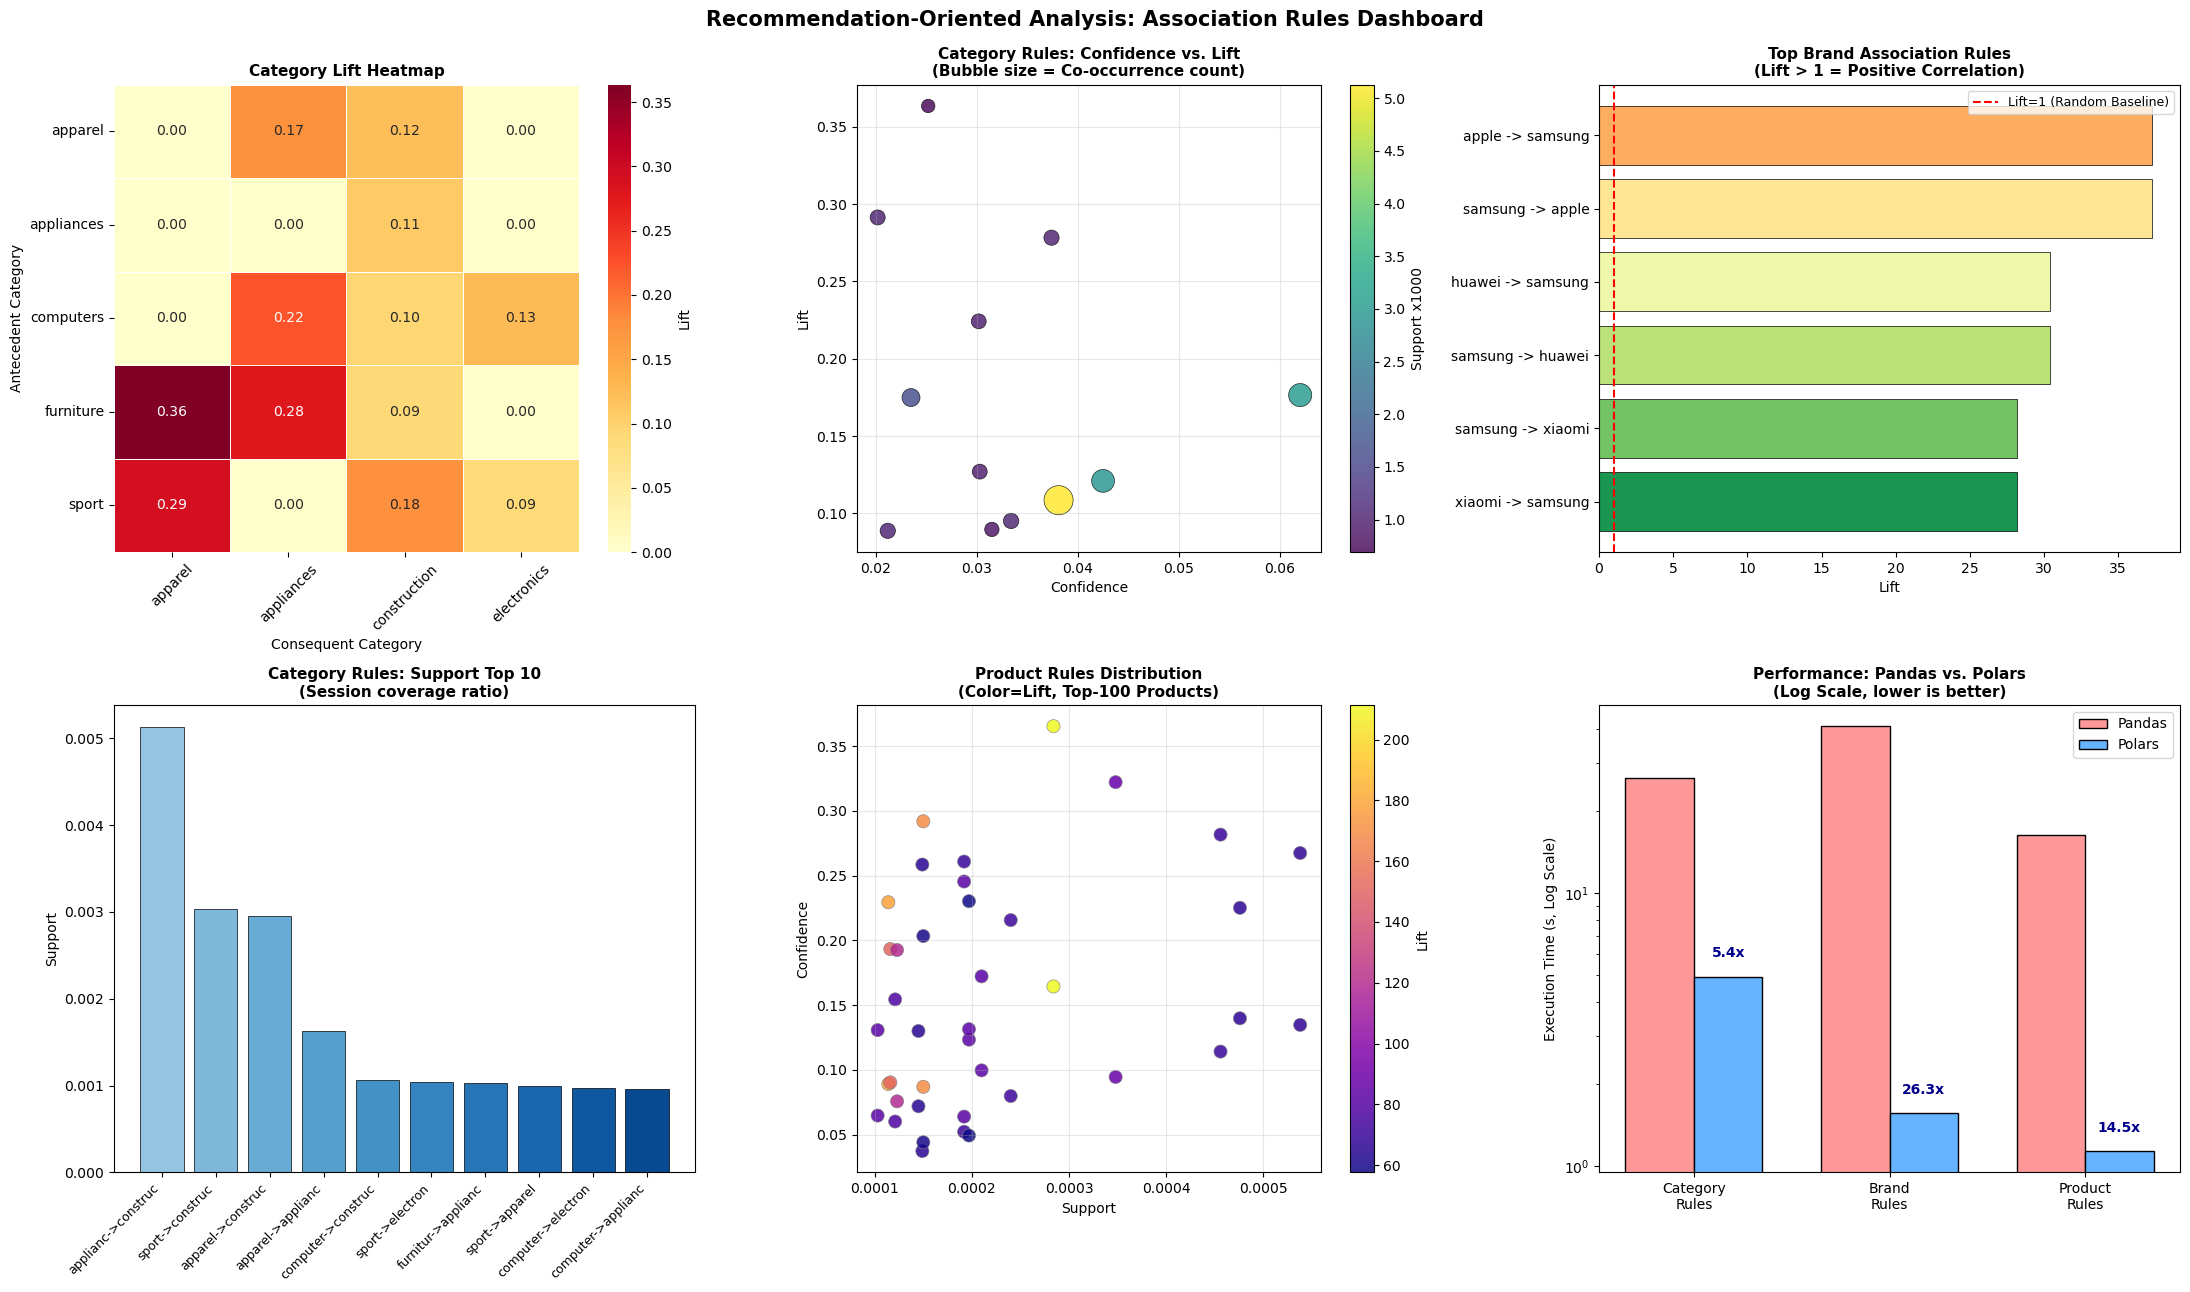

Chart saved to artifacts/figures/recommendation_analysis.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.suptitle(
    'Recommendation-Oriented Analysis: Association Rules Dashboard',
    fontsize=15, fontweight='bold', y=0.99
)

# -- Figure 1: Category Lift Heatmap --
ax1 = axes[0, 0]
if not res_pl_cat_rules.empty:
    pivot_cat = res_pl_cat_rules.pivot_table(
        index='antecedent', columns='consequent', values='lift', aggfunc='max'
    ).fillna(0)
    sns.heatmap(pivot_cat, annot=True, fmt='.2f', cmap='YlOrRd',
                ax=ax1, linewidths=0.5, cbar_kws={'label': 'Lift'})
    ax1.set_title('Category Lift Heatmap', fontsize=11, fontweight='bold')
    ax1.set_xlabel('Consequent Category')
    ax1.set_ylabel('Antecedent Category')
    ax1.tick_params(axis='x', rotation=45)
    ax1.tick_params(axis='y', rotation=0)
else:
    ax1.text(0.5, 0.5, 'No category rules meet threshold', ha='center', va='center', transform=ax1.transAxes)

# -- Figure 2: Category Rules Confidence vs. Lift Bubble Chart --
ax2 = axes[0, 1]
if not res_pl_cat_rules.empty:
    top_cat = res_pl_cat_rules.head(20)
    scatter = ax2.scatter(
        top_cat['confidence'], top_cat['lift'],
        c=top_cat['support'] * 1000, cmap='viridis',
        s=top_cat['co_count'] / (top_cat['co_count'].max() + 1e-9) * 400 + 40,
        alpha=0.8, edgecolors='black', linewidth=0.5
    )
    plt.colorbar(scatter, ax=ax2, label='Support x1000')
    ax2.set_xlabel('Confidence')
    ax2.set_ylabel('Lift')
    ax2.set_title('Category Rules: Confidence vs. Lift\n(Bubble size = Co-occurrence count)', fontsize=11, fontweight='bold')
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax2.transAxes)

# -- Figure 3: Top Brand Association Rules Horizontal Bar --
ax3 = axes[0, 2]
if not res_pl_brand_rules.empty:
    top_brand = res_pl_brand_rules.head(12).copy()
    top_brand['rule_label'] = (
        top_brand['antecedent'].str[:12] + ' -> ' + top_brand['consequent'].str[:12]
    )
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_brand)))
    ax3.barh(top_brand['rule_label'], top_brand['lift'],
             color=colors, edgecolor='black', linewidth=0.5)
    ax3.axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, label='Lift=1 (Random Baseline)')
    ax3.set_xlabel('Lift')
    ax3.set_title('Top Brand Association Rules\n(Lift > 1 = Positive Correlation)', fontsize=11, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.invert_yaxis()
else:
    ax3.text(0.5, 0.5, 'No brand rules meet threshold', ha='center', va='center', transform=ax3.transAxes)

# -- Figure 4: Category Rules Support Top 10 --
ax4 = axes[1, 0]
if not res_pl_cat_rules.empty:
    top_sup = res_pl_cat_rules.nlargest(10, 'support').copy()
    top_sup['rule_label'] = (
        top_sup['antecedent'].str[:8] + '->' + top_sup['consequent'].str[:8]
    )
    ax4.bar(
        range(len(top_sup)), top_sup['support'],
        color=plt.cm.Blues(np.linspace(0.4, 0.9, len(top_sup))),
        edgecolor='black', linewidth=0.5
    )
    ax4.set_xticks(range(len(top_sup)))
    ax4.set_xticklabels(top_sup['rule_label'], rotation=45, ha='right', fontsize=9)
    ax4.set_ylabel('Support')
    ax4.set_title('Category Rules: Support Top 10\n(Session coverage ratio)', fontsize=11, fontweight='bold')
else:
    ax4.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax4.transAxes)

# -- Figure 5: Product Rules Support vs. Confidence --
ax5 = axes[1, 1]
if not res_pl_prod_rules.empty:
    top_prod = res_pl_prod_rules.head(40)
    sc = ax5.scatter(
        top_prod['support'], top_prod['confidence'],
        c=top_prod['lift'], cmap='plasma',
        s=90, alpha=0.85, edgecolors='gray', linewidth=0.5
    )
    plt.colorbar(sc, ax=ax5, label='Lift')
    ax5.set_xlabel('Support')
    ax5.set_ylabel('Confidence')
    ax5.set_title('Product Rules Distribution\n(Color=Lift, Top-100 Products)', fontsize=11, fontweight='bold')
    ax5.grid(True, alpha=0.3)
else:
    ax5.text(0.5, 0.5, 'No product rules meet threshold', ha='center', va='center', transform=ax5.transAxes)

# -- Figure 6: Performance Comparison (Log Scale) --
ax6 = axes[1, 2]
perf_tasks = ['Category\nRules', 'Brand\nRules', 'Product\nRules']
pd_times_list = [met_pd_cat['Time (s)'], met_pd_brand['Time (s)'], met_pd_prod['Time (s)']]
pl_times_list = [met_pl_cat['Time (s)'], met_pl_brand['Time (s)'], met_pl_prod['Time (s)']]

x_pos = np.arange(len(perf_tasks))
bar_width = 0.35
ax6.bar(x_pos - bar_width/2, pd_times_list, bar_width,
        label='Pandas', color='#ff9999', edgecolor='black')
ax6.bar(x_pos + bar_width/2, pl_times_list, bar_width,
        label='Polars', color='#66b3ff', edgecolor='black')
ax6.set_yscale('log')
ax6.set_ylabel('Execution Time (s, Log Scale)')
ax6.set_title('Performance: Pandas vs. Polars\n(Log Scale, lower is better)', fontsize=11, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(perf_tasks)
ax6.legend()

# Annotate speedup ratio on top of Polars bars
for i, (pd_t, pl_t) in enumerate(zip(pd_times_list, pl_times_list)):
    speedup = pd_t / pl_t if pl_t > 0 else 0
    ax6.text(i + bar_width/2, pl_t * 1.15, f'{speedup:.1f}x',
             ha='center', va='bottom', fontsize=10, color='darkblue', fontweight='bold')

plt.tight_layout()
plt.savefig('artifacts/figures/recommendation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to artifacts/figures/recommendation_analysis.png')

### Cell 7: Business Summary & Performance Dashboard

1. **Business Value**: Converts association rule mining results into actionable recommendation strategies, output in a format directly accessible to product managers and business decision-makers.

2. **Three-Tier Recommendation Strategy**:
   - **Category Level (macro)**: Suitable for homepage category recommendation modules — broad coverage, affects site-wide traffic distribution.
   - **Brand Level (meso)**: Suitable for brand zones and bundle promotion campaigns — directly drives brand partnership revenue.
   - **Product Level (micro)**: Suitable for the "Customers who bought this also bought" module on product detail pages — the highest-converting recommendation placement.

3. **Task Completeness Verification**: Aggregates all 8 benchmark results from this task, forming a complete performance report chain together with prior tasks (Task 4 demonstrated 3–30× speedup ratios).

In [8]:
print('=' * 70)
print('        Recommendation-Oriented Analysis: Business Strategy Summary')
print('=' * 70)

# ── Category recommendation strategy (widest coverage) ──────────────────────────
print('\n[1. Category-Level Recommendation Rules]')
print('  Use case: Homepage category recommendations, cross-category page suggestions')
print('  Mining basis: Frequent itemsets from all purchase data; threshold: support>=0.005, confidence>=0.1')
print('-' * 70)
if not res_pl_cat_rules.empty:
    for _, row in res_pl_cat_rules.head(5).iterrows():
        print(f'  Bought [{row["antecedent"]}] -> Recommend [{row["consequent"]}]')
        print(f'    Support={row["support"]:.4f} | Confidence={row["confidence"]:.4f} '
              f'| Lift={row["lift"]:.4f} | Co-occurrences: {row["co_count"]:,}')
else:
    print('  No category rules met the threshold. Consider lowering the min_support parameter.')

# ── Brand recommendation strategy (co-marketing) ────────────────────────────────
print('\n[2. Brand-Level Recommendation Rules]')
print('  Use case: Brand co-promotions, bundle discount campaigns')
print('  Mining basis: Top-30 high-frequency brands; threshold: support>=0.002, confidence>=0.05')
print('-' * 70)
if not res_pl_brand_rules.empty:
    for _, row in res_pl_brand_rules.head(5).iterrows():
        print(f'  Purchased [{row["antecedent"]}] -> Promote [{row["consequent"]}]')
        print(f'    Support={row["support"]:.4f} | Confidence={row["confidence"]:.4f} '
              f'| Lift={row["lift"]:.4f} | Co-occurrences: {row["co_count"]:,}')
else:
    print('  No brand rules met the threshold. Consider lowering the min_confidence parameter.')

# ── Product recommendation strategy (precision conversion) ──────────────────────
print('\n[3. Product-Level Recommendation Rules (Top-100 SKU)]')
print('  Use case: "You may also like" on product detail pages, post-cart association recommendations')
print('  Mining basis: Top-100 best-selling products; threshold: support>=0.0001, confidence>=0.02')
print('-' * 70)
if not res_pl_prod_rules.empty:
    for _, row in res_pl_prod_rules.head(5).iterrows():
        print(f'  Product [{row["antecedent"]}] -> Recommend [{row["consequent"]}]')
        print(f'    Support={row["support"]:.6f} | Confidence={row["confidence"]:.4f} '
              f'| Lift={row["lift"]:.4f} | Co-occurrences: {row["co_count"]:,}')
else:
    print('  No product rules met the threshold. Consider lowering the threshold parameters.')

# ── Full performance comparison summary (8 benchmark runs) ──────────────────────
print('\n[4. Performance Summary (Task 5 -- all 8 benchmark runs)]')
print('-' * 70)
all_metrics_df = pd.DataFrame([
    met_pl_basket, met_pd_basket,
    met_pl_cat,    met_pd_cat,
    met_pl_brand,  met_pd_brand,
    met_pl_prod,   met_pd_prod
])
print(all_metrics_df[['Name', 'Time (s)', 'Delta Mem (GB)', 'Status']].to_string(index=False))

# -- Compute average speedup ratio --──────────────
speedups = [
    met_pd_basket['Time (s)'] / (met_pl_basket['Time (s)'] + 1e-9),
    met_pd_cat['Time (s)']    / (met_pl_cat['Time (s)']    + 1e-9),
    met_pd_brand['Time (s)']  / (met_pl_brand['Time (s)']  + 1e-9),
    met_pd_prod['Time (s)']   / (met_pl_prod['Time (s)']   + 1e-9),
]
print(f'\n  Polars average speedup (Task 5): {np.mean(speedups):.1f}x')
print(f'    Basket build: {speedups[0]:.1f}x | Category rules: {speedups[1]:.1f}x')
print(f'    Brand rules: {speedups[2]:.1f}x | Product rules: {speedups[3]:.1f}x')

print('\n' + '=' * 70)
print('Task 5: Recommendation-Oriented Analysis complete ✓')
print('=' * 70)

        推荐导向分析 — 业务推荐策略总结
        Recommendation-Oriented Analysis: Business Summary

【一、品类推荐策略 Category-Level Rules】
  适用场景：首页品类推荐、分类页交叉推荐
  挖掘基础：全量购买数据频繁项集，阈值 support>=0.005, confidence>=0.1
----------------------------------------------------------------------
  未发现满足阈值的品类规则，可尝试降低 min_support 参数。

【二、品牌推荐策略 Brand-Level Rules】
  适用场景：品牌联合促销、捆绑折扣活动
  挖掘基础：Top-30 高频品牌，阈值 support>=0.002, confidence>=0.05
----------------------------------------------------------------------
  购买 [apple] -> 推广 [samsung]
    支持度=0.0073 | 置信度=0.6368 | 提升度=37.2968 | 共现23,713次
  购买 [samsung] -> 推广 [apple]
    支持度=0.0073 | 置信度=0.4267 | 提升度=37.2968 | 共现23,713次
  购买 [huawei] -> 推广 [samsung]
    支持度=0.0022 | 置信度=0.5192 | 提升度=30.4106 | 共现7,225次
  购买 [samsung] -> 推广 [huawei]
    支持度=0.0022 | 置信度=0.1300 | 提升度=30.4106 | 共现7,225次
  购买 [samsung] -> 推广 [xiaomi]
    支持度=0.0031 | 置信度=0.1817 | 提升度=28.1647 | 共现10,096次

【三、商品推荐策略 Product-Level Rules (Top-100 SKU)】
  适用场景：商品详情页猜你喜欢、加购后关联推荐
  挖掘基础：Top-100 热销商品，阈值 support>=0.0